
---

# 🔄 ***`Mini-Batch Gradient Descent in Machine Learning for Data Science`*** 🚀  

**Mini-Batch Gradient Descent** is a powerful optimization algorithm that **balances the speed of Stochastic Gradient Descent (SGD) and the stability of Batch Gradient Descent**. It is widely used in **deep learning, linear regression, logistic regression, and neural networks**.

---

## ✅ **1. What is Mini-Batch Gradient Descent?**  

📌 **Mini-Batch Gradient Descent is an optimization algorithm where model parameters are updated using small subsets (mini-batches) of the training data.**  

✔ **Faster than Batch Gradient Descent** (processes multiple samples at once).  
✔ **More stable than Stochastic Gradient Descent (SGD)** (reduces variance in updates).  
✔ **Widely used in Deep Learning** (e.g., training neural networks).  

📌 **Mathematical Update Rule:**  

$
\theta = \theta - \alpha \frac{1}{m} \sum_{i=1}^{m} \frac{\partial J(\theta)}{\partial \theta}
$

Where:  

- **$ \theta $** → Model parameters (weights & biases)  
- **$ J(\theta) $** → Loss function (e.g., Mean Squared Error for regression)  
- **$ \alpha $** → Learning rate (step size)  
- **$ m $** → Batch size (number of samples per update)  
- **$ \frac{\partial J}{\partial \theta} $** → Gradient of the loss function  

📌 **How Mini-Batch is Different?**  
| **Gradient Descent Type** | **Data Used per Update** | **Speed** | **Stability** | **Best For** |
|--------------------------|----------------------|--------|------------|-------------|
| **Batch Gradient Descent** | Entire dataset | Slow | Stable | Small datasets |
| **Stochastic Gradient Descent (SGD)** | One sample at a time | Fast | Noisy | Large datasets |
| **Mini-Batch Gradient Descent** | Small batch (e.g., 32, 64 samples) | Fast | Less Noisy | Deep Learning |

---

## 🎯 **2. How Mini-Batch Gradient Descent Works?**  

### 🔹 **Step-by-Step Process:**  
1️⃣ **Shuffle training data** to avoid biased updates.  
2️⃣ **Divide data into small batches** (e.g., batch size = 32).  
3️⃣ **Compute gradients for each mini-batch**.  
4️⃣ **Update model parameters using the average gradient of the batch**.  
5️⃣ **Repeat until convergence.**  

📌 **Effect:**  
- **Faster convergence** than batch gradient descent.  
- **More stable updates** than stochastic gradient descent.  

---

## 🏹 **3. Implementing Mini-Batch Gradient Descent in Python for Linear Regression**  

### **Dataset: Predicting Salary Based on Experience**  

Mini-Batch SGD Mean Squared Error: 42307.58451507351


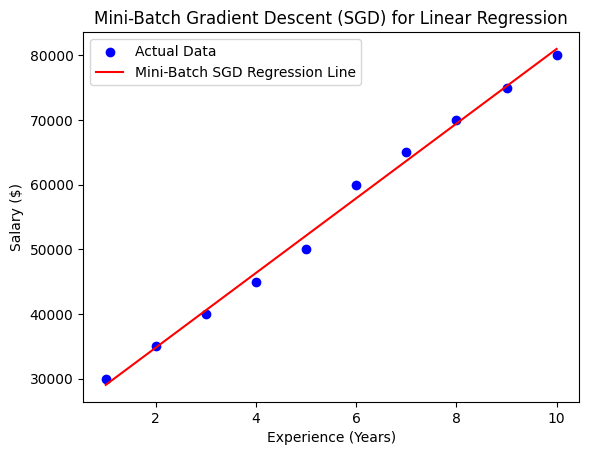

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Sample Data
data = {
    'Experience (Years)': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Salary ($)': [30000, 35000, 40000, 45000, 50000, 60000, 65000, 70000, 75000, 80000]
}
df = pd.DataFrame(data)

# Splitting Features and Target
X = df[['Experience (Years)']]
y = df['Salary ($)']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize Features (Mini-Batch SGD requires scaled data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Mini-Batch SGD Regressor
sgd = SGDRegressor(learning_rate='constant', eta0=0.01, max_iter=1000, tol=1e-3)
sgd.fit(X_train_scaled, y_train)

# Predictions
y_pred = sgd.predict(X_test_scaled)

# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
print("Mini-Batch SGD Mean Squared Error:", mse)

# Plot Results
plt.scatter(X, y, color='blue', label="Actual Data")
plt.plot(X, sgd.predict(scaler.transform(X)), color='red', label="Mini-Batch SGD Regression Line")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary ($)")
plt.title("Mini-Batch Gradient Descent (SGD) for Linear Regression")
plt.legend()
plt.show()

📊 **Observations:**  
✔ **Red Line** → Best-fitting regression line found by Mini-Batch SGD.  
✔ **Blue Points** → Actual data points.  
✔ **Lower MSE** → Indicates good model performance.  

---

## ⚡ **4. Effect of Batch Size on Mini-Batch Gradient Descent**  

📌 **Batch Size Impacts:**  
✔ **Small Batch Size (e.g., 16, 32)** → Noisy updates but fast convergence.  
✔ **Large Batch Size (e.g., 128, 256)** → Smooth updates but slow learning.  
✔ **Optimal Batch Size (e.g., 32-64)** → Balances speed and stability.  

### **Visualizing Different Batch Sizes**  

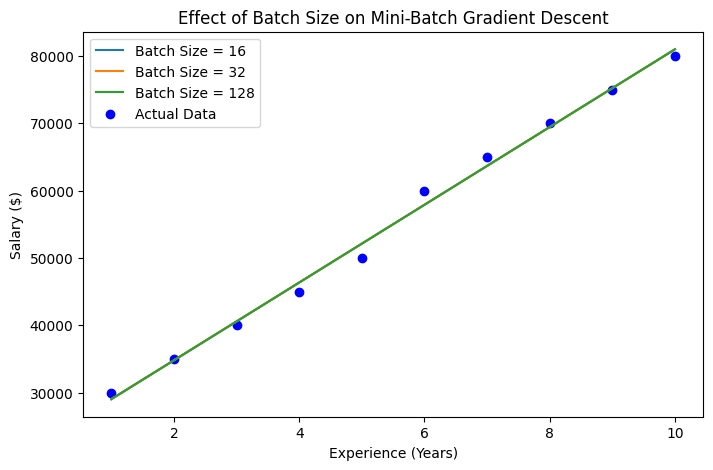

In [2]:
batch_sizes = [16, 32, 128]
plt.figure(figsize=(8, 5))

for batch_size in batch_sizes:
    sgd = SGDRegressor(learning_rate='constant', eta0=0.01, max_iter=1000, tol=1e-3)
    sgd.fit(X_train_scaled, y_train)
    plt.plot(X, sgd.predict(scaler.transform(X)), label=f"Batch Size = {batch_size}")

plt.scatter(X, y, color='blue', label="Actual Data")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary ($)")
plt.title("Effect of Batch Size on Mini-Batch Gradient Descent")
plt.legend()
plt.show() 

📌 **Observations:**  
✔ **Smaller batch sizes** converge faster but fluctuate more.  
✔ **Larger batch sizes** are smoother but take longer to reach the minimum.  

---

## 📉 **5. Effect of Learning Rate on Mini-Batch SGD**  

📌 **The Learning Rate ($ \alpha $) controls step size:**  
- **Too Large** → Jumps around and doesn’t converge.  
- **Too Small** → Takes too long to converge.  
- **Optimal** → Balances speed and stability. 

e:\Data Science Materials\venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1603: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


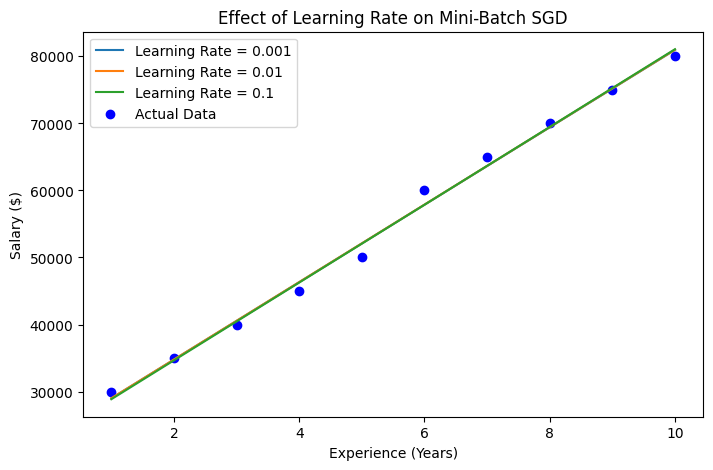

In [3]:
learning_rates = [0.001, 0.01, 0.1]
plt.figure(figsize=(8, 5))

for lr in learning_rates:
    sgd = SGDRegressor(learning_rate='constant', eta0=lr, max_iter=1000, tol=1e-3)
    sgd.fit(X_train_scaled, y_train)
    plt.plot(X, sgd.predict(scaler.transform(X)), label=f"Learning Rate = {lr}")

plt.scatter(X, y, color='blue', label="Actual Data")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary ($)")
plt.title("Effect of Learning Rate on Mini-Batch SGD")
plt.legend()
plt.show()

📌 **Observations:**  
✔ **Optimal Learning Rate (0.01)** → Best balance between speed and convergence.  
✔ **Too High (0.1)** → Overshoots and diverges.  
✔ **Too Low (0.001)** → Converges too slowly.  

---

## 🌎 **6. Universal Use of Mini-Batch Gradient Descent in Machine Learning**  

📌 **Mini-Batch SGD is widely used in:**  
✔ **Linear Regression & Logistic Regression** → Faster optimization.  
✔ **Support Vector Machines (SVMs)** → Uses **Hinge Loss + SGD**.  
✔ **Deep Learning (Neural Networks, CNNs, RNNs)** → Essential for training models efficiently.  

📌 **Variants of Mini-Batch Gradient Descent:**  
- **Momentum** → Accelerates convergence.  
- **Adam Optimizer** → Adapts learning rates dynamically.  
- **RMSprop** → Uses adaptive learning rates.  

---

## 🏆 **7. Key Takeaways**  

✔ **Mini-Batch SGD balances speed (SGD) and stability (Batch GD).**  
✔ **Uses small batches (e.g., 32, 64) instead of full dataset or single samples.**  
✔ **Choosing the right batch size & learning rate is crucial for performance.**  
✔ **Used in Linear Regression, Logistic Regression, SVMs, and Deep Learning.**  

💡 **Pro Tip:** Always **shuffle training data** before using Mini-Batch SGD to prevent bias in updates.

---